In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [74]:
hubble = np.loadtxt("/Users/JoanaUCD/Library/CloudStorage/OneDrive-UniversityCollegeDublin/Labs/labs-files/labs code/HubbleRS values.txt")

appmag = hubble[:,0]
kline = hubble[:,1]
hline = hubble[:,2]

a = 1e-13

klinekm = kline*a
hlinekm = hline*a

In [75]:
D = (10**((appmag + 22 + 5)/5))
print(D)
print("D in Mpc")
Dmpc = D / 1e6
print(Dmpc)
labk = 3.9937e-10
labh = 3.9685e-10
print("Delta")
DeltaK = klinekm - labk
print(DeltaK)
DeltaH = hlinekm - labh
print(DeltaH)
c = 3e5
print("velocity")
vK = c * (DeltaK/labk) 
print(vK)
vH = c * (DeltaH/labh) 
print(vH)
print("average")
avgv = (vK + vH)/2
print(avgv)

[2.01372425e+08 1.98609492e+08 5.94292159e+08 5.99791076e+08
 8.12830516e+07 7.76247117e+07 5.64936975e+08 5.54625713e+08
 2.60615355e+08 2.95120923e+08 4.26579519e+07 7.27779805e+07]
D in Mpc
[201.37242499 198.60949174 594.29215862 599.79107626  81.28305162
  77.62471166 564.93697481 554.62571296 260.615355   295.12092267
  42.65795188  72.77798045]
Delta
[ 1.373e-11  1.363e-11  4.903e-11  4.903e-11  1.830e-12  1.830e-12
  4.513e-11  4.513e-11  2.153e-11  2.153e-11 -2.070e-12  1.830e-12]
[ 1.9750e-11  1.9850e-11 -3.9685e-10 -3.9685e-10  7.9500e-12  7.8500e-12
  5.1650e-11  5.1550e-11  2.7850e-11  2.7750e-11  3.9500e-12  7.9500e-12]
velocity
[10313.74414703 10238.62583569 36830.50805018 36830.50805018
  1374.66509753  1374.66509753 33900.8939079  33900.8939079
 16172.97243158 16172.97243158 -1554.94904475  1374.66509753]
[  14930.07433539   15005.66964848 -300000.         -300000.
    6009.8273907     5934.23207761   39044.97921129   38969.3838982
   21053.29469573   20977.69938264    

[12622.   12622.   36831.   36831.    3692.2   3654.4  36472.   36435.
 18613.   18575.     715.53  3692.2 ]
[12622. 12622.]
[36831. 36831.]
[3692.2 3654.4]
[36472. 36435.]
[18613. 18575.]
[ 715.53 3692.2 ]


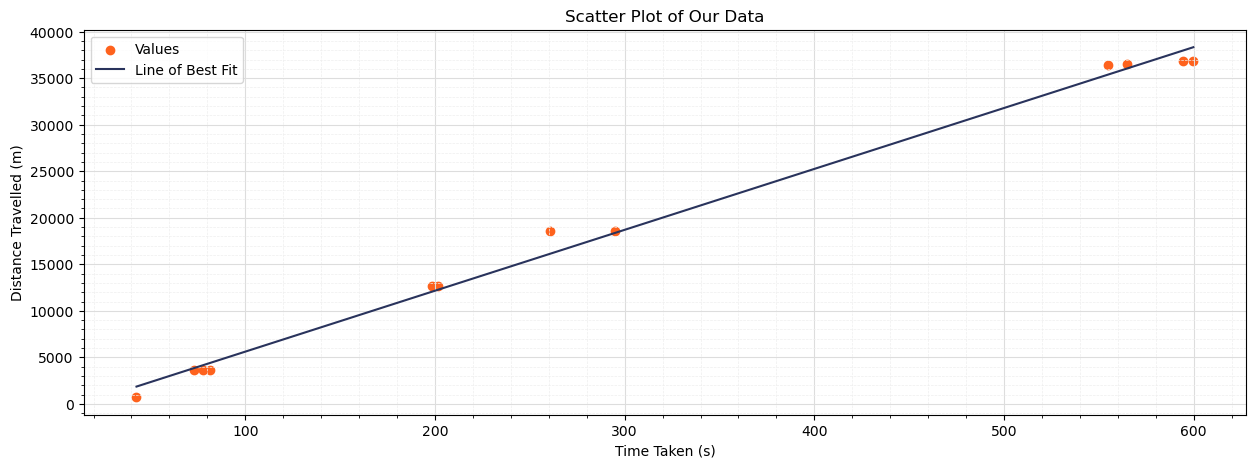

65.45021072792693


In [48]:
"""vel = hubble[:,3]
print(vel)
veluma1 = vel[0:2]
print(veluma1)
veluma2 = vel[2:4]
print(veluma2)
velcoma = vel[4:6]
print(velcoma)
velboot = vel[6:8]
print(velboot)
velcrbor = vel[8:10]
print(velcrbor)
velsag = vel[10:12]
print(velsag)

slope, intercept = np.polyfit(Dmpc, vel, 1)

plt.figure(figsize=(15,5))

# Plot
plt.scatter(Dmpc, vel, color="#FE621D")


#Grid
plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD")
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--")

#Line of Best Fit
plt.plot(np.unique(Dmpc), np.poly1d(np.polyfit(Dmpc, vel, 1))(np.unique(Dmpc)), color = "#29335C")

# Labels
plt.title("Scatter Plot of Our Data")
plt.xlabel("Time Taken (s)")
plt.ylabel("Distance Travelled (m)")
plt.legend(["Values", "Line of Best Fit", "Error"])

plt.show()

print(np.abs(slope))
"""

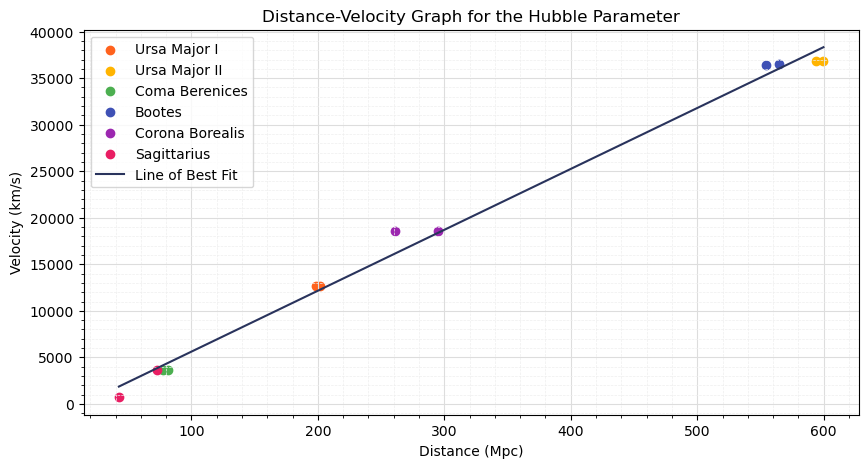

65.45021072792693


In [77]:
vel = hubble[:,3]
veluma1 = vel[0:2]
veluma2 = vel[2:4]
velcoma = vel[4:6]
velboot = vel[6:8]
velcrbor = vel[8:10]
velsag = vel[10:12]

groups = {
    "Ursa Major I": (Dmpc[:2], veluma1), 
    "Ursa Major II": (Dmpc[2:4], veluma2),
    "Coma Berenices": (Dmpc[4:6], velcoma),
    "Bootes": (Dmpc[6:8], velboot),
    "Corona Borealis": (Dmpc[8:10], velcrbor),
    "Sagittarius": (Dmpc[10:12], velsag)
}

colors = {
    "Ursa Major I": "#FF621D",
    "Ursa Major II": "#FFB400",
    "Coma Berenices": "#4CAF50",
    "Bootes": "#3F51B5",
    "Corona Borealis": "#9C27B0",
    "Sagittarius": "#E91E63"
}

plt.figure(figsize=(10, 5))

# Plot each group with its corresponding x-values and color
for label, (x_vals, y_vals) in groups.items():
    plt.scatter(x_vals, y_vals, label=label, color=colors[label])

# Grid settings
plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD")
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--")

# Line of Best Fit
slope, intercept = np.polyfit(Dmpc, vel, 1)
plt.plot(
    np.unique(Dmpc),
    np.polyval([slope, intercept], np.unique(Dmpc)),
    label="Line of Best Fit",
    color="#29335C"
)

# Labels and legend
plt.title("Distance-Velocity Graph for the Hubble Parameter")
plt.xlabel("Distance (Mpc)")
plt.ylabel("Velocity (km/s)")
plt.legend()

plt.show()

# Print slope
print(np.abs(slope))


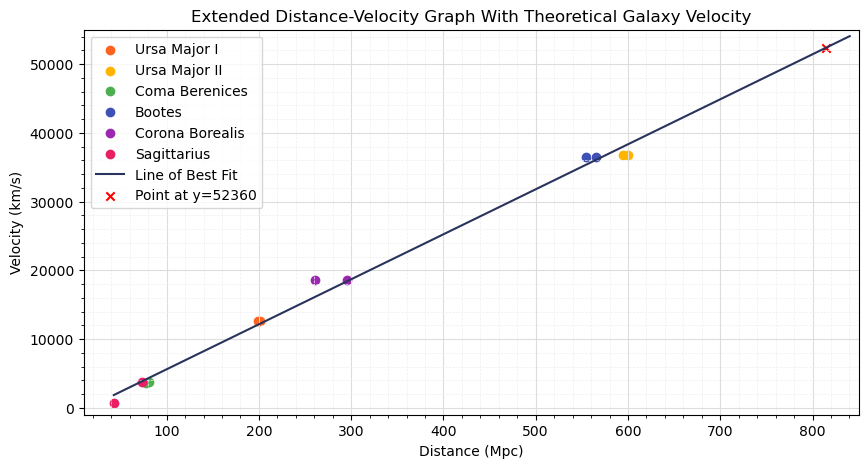

In [72]:
extended_x = np.linspace(min(Dmpc), 55_000 / slope, 1000) 

y_point = 52_360

x_point = (y_point - intercept) / slope

plt.figure(figsize=(10, 5))
for label, (x_vals, y_vals) in groups.items():
    plt.scatter(x_vals, y_vals, label=label, color=colors[label])

# Grid settings
plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD")
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--")

# Extended line of best fit
plt.plot(
    extended_x,
    np.polyval([slope, intercept], extended_x),
    label="Line of Best Fit",
    color="#29335C"
)

plt.scatter(x_point, y_point, color="red", label=f"Point at y={y_point}", marker='x')

plt.ylim(-1000, 55_000)
plt.xlim(10, 850)

# Labels and legend
plt.title("Extended Distance-Velocity Graph With Theoretical Galaxy Velocity")
plt.xlabel("Distance (Mpc)")
plt.ylabel("Velocity (km/s)")
plt.legend()

plt.show()

